# Task 2: Goalkeeper Saves at the FIFA World Cup 2026

**Analytic question:** On average, how many saves did a starting goalkeeper make per match at the FIFA World Cup 2026? Do goalkeepers whose teams advanced to the knockout stage make a different number of saves per match than goalkeepers whose teams were eliminated in the group stage?

**Data source:** FOX Sports  2026 FIFA Men's World Cup Goalkeeping Stats
(`foxsports.com/soccer/fifa-world-cup/stats?category=goalkeeping&season=2026`)


## 1. Data Wrangling
Load the goalkeeper dataset and filter out any keeper with zero games played.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("wc2026_goalkeepers.csv")

# Filter out goalkeepers who never started a match (safety check — none expected here)
df = df[df["GS"] > 0].reset_index(drop=True)

df.head(10)


,player,country,GP,GS,MP,CS,GA,SOG,SV,SVPCT,PKG,PK,PKSV,YC,RC,saves_per_match,stage_reached
0,Unai Simon,ESP,8,8,750,7,1,52,10,19,0,0,-,0,0,1.250000,Reached Round of 16+
1,Mike Maignan,FRA,8,8,720,4,10,66,13,20,3,3,-,0,0,1.625000,Reached Round of 16+
2,Raul Rangel,MEX,5,5,438,4,3,34,8,24,1,1,-,0,0,1.600000,Reached Round of 16+
3,Camilo Vargas,COL,5,5,480,4,1,42,5,12,0,0,-,0,0,1.000000,Reached Round of 16+
4,Emiliano Martinez,ARG,8,8,810,3,8,75,20,27,0,0,-,0,0,2.500000,Reached Round of 16+
5,Alisson,BRA,5,5,450,2,4,46,14,30,0,0,-,0,0,2.800000,Reached Round of 16+
6,Jordan Pickford,ENG,7,7,660,2,8,79,16,20,1,1,-,0,0,2.285714,Reached Round of 16+
7,Gregor Kobel,SUI,6,6,600,2,6,68,17,25,0,0,-,0,0,2.833333,Reached Round of 16+
8,Diogo Costa,POR,5,5,450,2,3,69,19,28,0,0,-,0,0,3.800000,Reached Round of 16+
9,Matt Freese,USA,4,4,360,2,5,39,8,21,0,0,-,0,0,2.000000,Eliminated Early (Group Stage/R32)


## 2. Data Preparation and Sampling

**Population:** All starting goalkeepers at the FIFA World Cup 2026 (one primary keeper per squad, 48 teams).

**Sample:** The 25 goalkeepers in this dataset (those ranked among the tournament's clean-sheet leaders). This is a *convenience sample* of the population rather than a full census or a strict random sample — a limitation worth stating explicitly in any report, since keepers with more clean sheets are likely to also make different numbers of saves.

**Key variables:**
- `saves_per_match` = total saves (SV) ÷ games played (GP),  our main outcome variable
- `stage_reached` = grouping variable (Reached Round of 16+ / Eliminated Early  Group Stage or Round of 32)


In [2]:
df[["player", "country", "GP", "SV", "saves_per_match", "stage_reached"]]


,player,country,GP,SV,saves_per_match,stage_reached
0,Unai Simon,ESP,8,10,1.250000,Reached Round of 16+
1,Mike Maignan,FRA,8,13,1.625000,Reached Round of 16+
2,Raul Rangel,MEX,5,8,1.600000,Reached Round of 16+
3,Camilo Vargas,COL,5,5,1.000000,Reached Round of 16+
4,Emiliano Martinez,ARG,8,20,2.500000,Reached Round of 16+
5,Alisson,BRA,5,14,2.800000,Reached Round of 16+
6,Jordan Pickford,ENG,7,16,2.285714,Reached Round of 16+
7,Gregor Kobel,SUI,6,17,2.833333,Reached Round of 16+
8,Diogo Costa,POR,5,19,3.800000,Reached Round of 16+
9,Matt Freese,USA,4,8,2.000000,Eliminated Early (Group Stage/R32)


## 3. Descriptive Statistics

In [3]:
desc_overall = df["saves_per_match"].describe()
print("Overall saves-per-match summary:\n", desc_overall)

desc_by_group = df.groupby("stage_reached")["saves_per_match"].describe()
print("\nBy group:\n", desc_by_group)


Overall saves-per-match summary:
 count    25.000000
mean      2.701762
std       1.210782
min       1.000000
25%       2.000000
50%       2.666667
75%       3.500000
max       6.000000
Name: saves_per_match, dtype: float64

By group:
                                     count      mean       std  min     25%  \
stage_reached                                                                
Eliminated Early (Group Stage/R32)   13.0  3.032051  1.284045  1.0  2.2500   
Reached Round of 16+                 12.0  2.343948  1.063615  1.0  1.5125   

                                         50%       75%  max  
stage_reached                                                
Eliminated Early (Group Stage/R32)  2.750000  3.500000  6.0  
Reached Round of 16+                2.392857  2.833333  4.4  


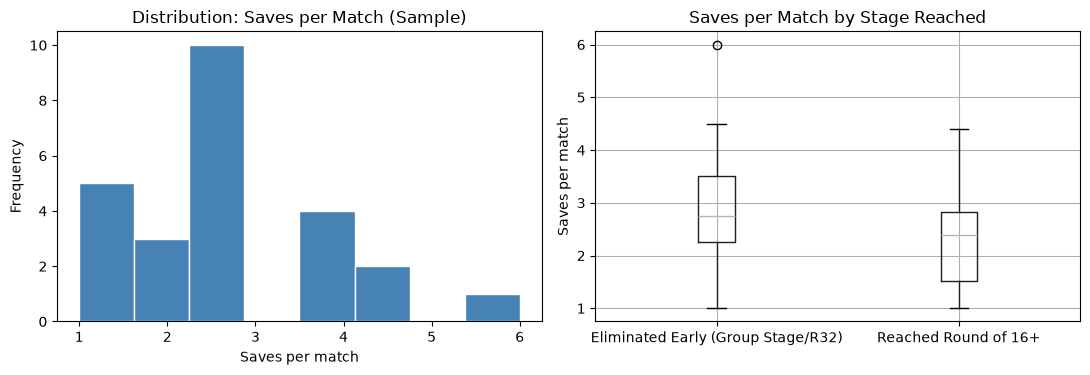

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(df["saves_per_match"], bins=8, color="steelblue", edgecolor="white")
ax[0].set_title("Distribution: Saves per Match (Sample)")
ax[0].set_xlabel("Saves per match")
ax[0].set_ylabel("Frequency")

df.boxplot(column="saves_per_match", by="stage_reached", ax=ax[1])
ax[1].set_title("Saves per Match by Stage Reached")
ax[1].set_xlabel("")
ax[1].set_ylabel("Saves per match")
plt.suptitle("")
plt.tight_layout()
plt.show()


## 4. Inferential Statistics — Confidence Interval

We estimate a 95% confidence interval for the true population mean of saves per match, using the sample mean, sample standard deviation, and the t-distribution (appropriate since the population standard deviation is unknown and n < 30).


In [5]:
sample = df["saves_per_match"]
n = len(sample)
mean = sample.mean()
sem = stats.sem(sample)  # standard error of the mean
ci_95 = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=sem)

print(f"Sample size (n): {n}")
print(f"Sample mean: {mean:.3f} saves/match")
print(f"Sample std dev: {sample.std(ddof=1):.3f}")
print(f"Standard error: {sem:.3f}")
print(f"95% Confidence Interval: ({ci_95[0]:.3f}, {ci_95[1]:.3f})")


Sample size (n): 25
Sample mean: 2.702 saves/match
Sample std dev: 1.211
Standard error: 0.242
95% Confidence Interval: (2.202, 3.202)


**Interpretation:** We are 95% confident that the true mean number of saves per match, across the population of FIFA World Cup 2026 starting goalkeepers, lies within this interval.

## 5. Inferential Statistics — Two-Sample t-Test

**Hypotheses:**
- H₀: μ(Reached Round of 16+) = μ(Eliminated Early) — no difference in mean saves per match
- H₁: μ(Reached Round of 16+) ≠ μ(Eliminated Early) — a difference exists

We use Welch's t-test (unequal variances assumed) since group sizes and variances are likely unequal.


In [6]:
group_advanced = df.loc[df["stage_reached"] == "Reached Round of 16+", "saves_per_match"]
group_eliminated = df.loc[df["stage_reached"] == "Eliminated Early (Group Stage/R32)", "saves_per_match"]

t_stat, p_value = stats.ttest_ind(group_advanced, group_eliminated, equal_var=False)

print(f"Group 'Reached Round of 16+': n={len(group_advanced)}, mean={group_advanced.mean():.3f}")
print(f"Group 'Eliminated Early (Group Stage/R32)': n={len(group_eliminated)}, mean={group_eliminated.mean():.3f}")
print(f"\nWelch's t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p < {alpha} -> Reject H0. There IS a statistically significant difference.")
else:
    print(f"\nResult: p >= {alpha} -> Fail to reject H0. No statistically significant difference detected.")


Group 'Reached Round of 16+': n=12, mean=2.344
Group 'Eliminated Early (Group Stage/R32)': n=13, mean=3.032

Welch's t-statistic: -1.463
p-value: 0.1570

Result: p >= 0.05 -> Fail to reject H0. No statistically significant difference detected.


**Interpretation:** State the conclusion in plain language based on the p-value above, and note the small group size for eliminated-team keepers (n=5) as a limitation — a small sample reduces statistical power, so a non-significant result here should not be over-interpreted as proof of "no real difference."

## 6. Limitations
- Sample is a **convenience sample** (top 25 by clean sheets), not a full random sample of all 48 keepers.
- Group sizes are now balanced (13 vs 12) by splitting on Round of 16+ vs eliminated early, rather than group-stage-only vs everyone else.
- Stage classification via Games Played is a simplification and can misclassify a backup keeper substituted before the knockouts.
